In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import scipy.ndimage as ndi

from src.data.paths import project_dir
from src.data.analysis import read_tiff_img, Circle, create_circular_mask
from src.data.detector import DetectorDataCollection, DetectorData, DetectorImage

In [11]:
colors = [(0, 1, 0), (1, 0, 0)]  # green -> red
cmap_name = 'custom_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors)

# Data loading

## Paths

In [12]:
# local paths
base_path = project_dir / 'data' / 'raw'
#base_path = Path.home() / 'OneDrive - ifj.edu.pl' / 'Projects' / 'MB_foils'

base_path.exists()

True

In [13]:
proton_path = base_path / '2025-10-09'
proton_path.exists()

True

In [14]:
# dump the smoothed dictionary into a pickle
import pickle
with open(proton_path / 'proton_denoised_data.pkl', 'rb') as f:
    data = pickle.load(f)

In [15]:
left_id = 1
right_id = 2

In [16]:
left_det = data.data[left_id]
right_det = data.data[right_id]

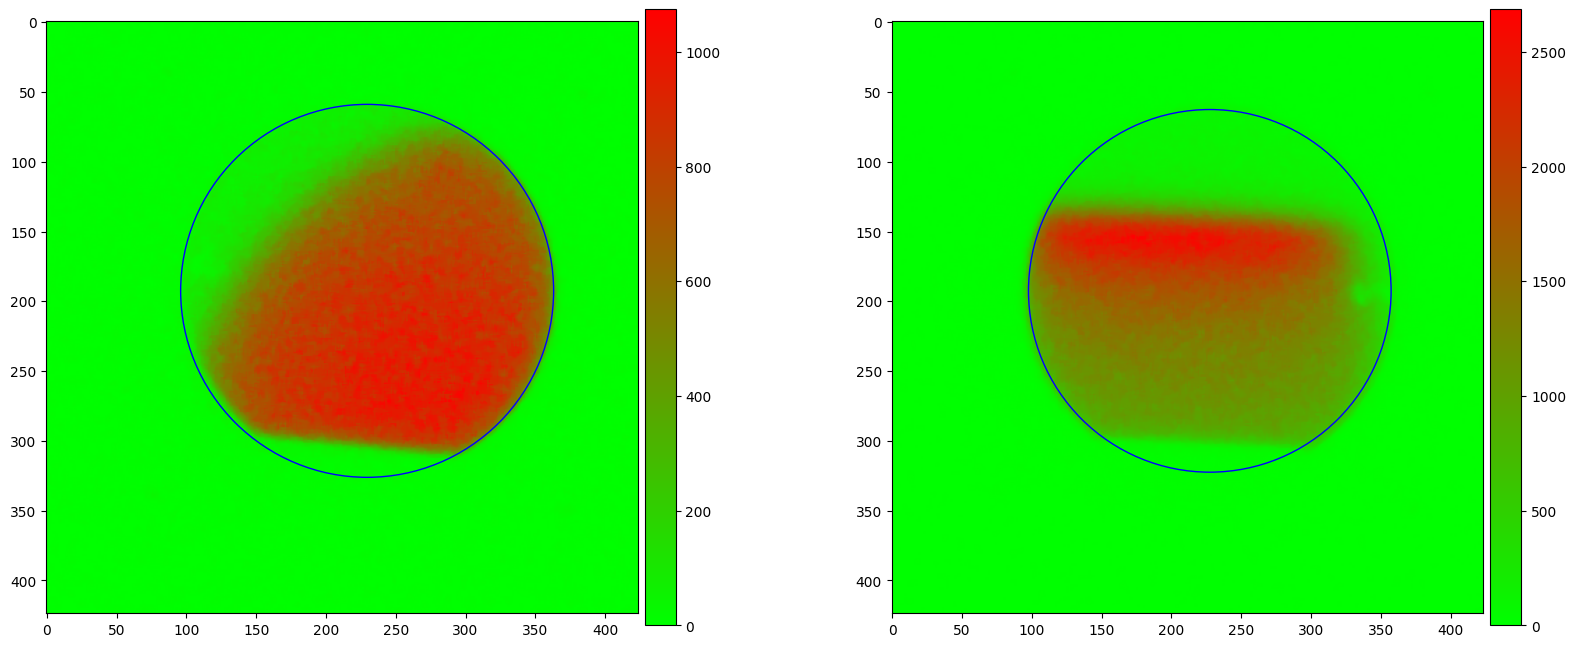

In [20]:
# plot left and right detectors
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
pos1 = axs[0].imshow(left_det.raw.image, cmap=custom_cmap)
axs[0].add_patch(
                plt.Circle(
                        (left_det.circle.x, left_det.circle.y), 
                        left_det.circle.r, 
                        color='blue', 
                        fill=False, 
                 )
)
plt.colorbar(pos1, ax=axs[0], shrink=0.8, pad=0.01)
pos2 = axs[1].imshow(right_det.raw.image, cmap=custom_cmap)
axs[1].add_patch(
                plt.Circle(
                        (right_det.circle.x, right_det.circle.y), 
                        right_det.circle.r, 
                        color='blue', 
                        fill=False, 
                 )
)
plt.colorbar(pos2, ax=axs[1], shrink=0.8, pad=0.01)
plt.show()
